In [1]:
!pip install wandb
import wandb
import os
import yaml
from shutil import copytree, ignore_patterns
import xml.etree.ElementTree as ET

In [2]:
root_path = '/kaggle/input/fruit-images-for-object-detection'
os.listdir(root_path)

['train_zip', 'test_zip']

In [3]:
train_data_path = os.path.join(root_path,'/kaggle/input/fruit-images-for-object-detection/train_zip/train')
test_data_path = os.path.join(root_path,'/kaggle/input/fruit-images-for-object-detection/test_zip/test')

In [4]:
'''All .xml and .jpg file names'''
train_data_description = os.listdir(train_data_path)
test_data_description = os.listdir(test_data_path)

In [5]:
'''train_annotaion_file_paths and test_annotation_file_paths contains all .xml file paths
   train_image_file_paths and test_image_file_paths contains all .jpg file paths'''
train_annotation_file_paths = [os.path.join(train_data_path,i) for i in train_data_description if '.xml' in i]
train_image_file_paths = [os.path.join(train_data_path,i) for i in train_data_description if '.jpg' in i]

test_annotation_file_paths = [os.path.join(test_data_path,i) for i in test_data_description if '.xml' in i]
test_image_file_paths = [os.path.join(test_data_path,i) for i in test_data_description if '.jpg' in i]

In [6]:
print(f'length of training Data {len(train_image_file_paths)}, length of test data {len(test_image_file_paths)}')

length of training Data 240, length of test data 60


In [7]:
'''Creating required directories to labels'''
for i in ['train/labels','test/labels']:
    os.makedirs(os.path.join('/kaggle/working/object_detection/',i))

In [8]:
import os
from shutil import copytree, ignore_patterns, rmtree

train_data_path = '/kaggle/input/fruit-images-for-object-detection/train_zip/train'  # Replace with the actual path
test_data_path = '/kaggle/input/fruit-images-for-object-detection/test_zip/test'    # Replace with the actual path
train_dest_path = '/kaggle/working/object_detection/train'
test_dest_path = '/kaggle/working/object_detection/test/labels'

# Ensure source directories exist
if not os.path.exists(train_data_path):
    print(f"Error: Training data path not found: {train_data_path}")
else:
    try:
        # Remove destination directory if it exists to avoid FileExistsError
        if os.path.exists(train_dest_path):
            rmtree(train_dest_path)
            print(f"Warning: Removed existing directory: {train_dest_path}")

        copytree(train_data_path, train_dest_path, ignore=ignore_patterns('*.xml'))
        print(f"Successfully copied images from '{train_data_path}' to '{train_dest_path}', ignoring XML files.")
    except Exception as e:
        print(f"Error copying training images: {e}")

if not os.path.exists(test_data_path):
    print(f"Error: Testing data path not found: {test_data_path}")
else:
    try:
        # Remove destination directory if it exists to avoid FileExistsError
        if os.path.exists(test_dest_path):
            rmtree(test_dest_path)
            print(f"Warning: Removed existing directory: {test_dest_path}")

        copytree(test_data_path, test_dest_path, ignore=ignore_patterns('*.xml'))
        print(f"Successfully copied images from '{test_data_path}' to '{test_dest_path}', ignoring XML files.")
    except Exception as e:
        print(f"Error copying testing images: {e}")

Successfully copied images from '/kaggle/input/fruit-images-for-object-detection/train_zip/train' to '/kaggle/working/object_detection/train', ignoring XML files.
Successfully copied images from '/kaggle/input/fruit-images-for-object-detection/test_zip/test' to '/kaggle/working/object_detection/test/labels', ignoring XML files.


In [9]:
def convert_xml_to_txt(label_path,xml_file,class_dict,destination_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    x=root.find('filename').text
    txt_file = x.replace('.jpg','.txt')
    txt_file = os.path.join(destination_file,txt_file)
    with open(txt_file,'w') as f:
        for obj in root.findall('object'):
            class_name = obj.find('name').text
            if class_name not in class_dict:
                continue
            class_id = class_dict[class_name]
            bbox = obj.find('bndbox')
            xmin = int(bbox.find('xmin').text)
            xmax = int(bbox.find('xmax').text)
            ymin = int(bbox.find('ymin').text)
            ymax = int(bbox.find('ymax').text)
            
            image_width = int(root.find('size/width').text)
            image_height = int(root.find('size/height').text)
            
            x_center = (xmin + xmax) / 2 / image_width if image_width != 0 else (xmin + xmax) / 2
            y_center = (ymin + ymax) / 2 / image_height if image_height != 0 else (ymin + ymax) / 2
            width = (xmax - xmin) / image_width if image_width != 0 else (xmax - xmin)
            height = (ymax - ymin) / image_height if image_height != 0 else (ymax - ymin)
             
            line = f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n"
            f.write(line)

In [10]:
def convert_xml_to_txt(label_path, xml_file, class_dict, destination_file):
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        base_name = os.path.splitext(os.path.basename(xml_file))[0]
        txt_file_name = base_name + '.txt'
        txt_file_path = os.path.join(destination_file, txt_file_name)
        with open(txt_file_path, 'w') as f:
            for obj in root.findall('object'):
                class_name = obj.find('name').text
                if class_name in class_dict:
                    class_id = class_dict[class_name]
                    bbox = obj.find('bndbox')
                    xmin = int(bbox.find('xmin').text)
                    ymin = int(bbox.find('ymin').text)
                    xmax = int(bbox.find('xmax').text)
                    ymax = int(bbox.find('ymax').text)

                    image_width = int(root.find('size/width').text)
                    image_height = int(root.find('size/height').text)

                    x_center = (xmin + xmax) / 2 / image_width if image_width != 0 else (xmin + xmax) / 2
                    y_center = (ymin + ymax) / 2 / image_height if image_height != 0 else (ymin + ymax) / 2
                    width = (xmax - xmin) / image_width if image_width != 0 else (xmax - xmin)
                    height = (ymax - ymin) / image_height if image_height != 0 else (ymax - ymin)

                    line = f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n"
                    f.write(line)
                else:
                    print(f"Warning: Class '{class_name}' not found in class dictionary.")
    except FileNotFoundError:
        print(f"Error: XML file not found: {xml_file}")
    except ET.ParseError:
        print(f"Error: Could not parse XML file: {xml_file}")
    except Exception as e:
        print(f"An error occurred while processing {xml_file}: {e}")

In [11]:
import os

class_dict = {'apple': 0, 'banana': 1, 'orange': 2}

# Create destination directory for training labels if it doesn't exist
train_dest_path = '/kaggle/working/object_detection/train/labels/'
os.makedirs(train_dest_path, exist_ok=True)
for i in train_annotation_file_paths:
    convert_xml_to_txt(train_data_path, i, class_dict, train_dest_path)

# Create destination directory for testing labels if it doesn't exist
test_dest_path = '/kaggle/working/object_detection/test/labels/'
os.makedirs(test_dest_path, exist_ok=True)
for i in test_annotation_file_paths:
    convert_xml_to_txt(test_data_path, i, class_dict, test_dest_path)

In [12]:
'''yaml file path, you can check the file'''
yaml_path = "/kaggle/input/yamldata/data.yaml"

In [13]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.8/974.8 kB 16.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 78.9 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found

In [14]:
from ultralytics import YOLO
model = YOLO('yolov8n.yaml')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [15]:
pip install ultralytics opencv-python

Note: you may need to restart the kernel to use updated packages.


In [1]:
import cv2
import torch
from ultralytics import YOLO
import os

# Load the YOLOv8 model
model = YOLO('yolov8n.pt')  # You can change 'yolov8n.pt' to other sizes

# Path to the folder containing images
images_folder = '/kaggle/working/object_detection/train'  # Replace with the actual path

# Output folder to save processed images
output_folder = '/kaggle/working/object_detection/test/labels'  # Replace with the desired output path
os.makedirs(output_folder, exist_ok=True)

# Get a list of all image files in the input folder
image_files = [f for f in os.listdir(images_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

if not image_files:
    print(f"No image files found in the folder: '{images_folder}'")
    exit()

for image_file in image_files:
    image_path = os.path.join(images_folder, image_file)
    try:
        # Perform inference on the image
        results = model(image_path)

        # Get the original image with detections drawn
        annotated_frame = results[0].plot()

        # Save the annotated image to the output folder
        output_path = os.path.join(output_folder, f'annotated_{image_file}')
        cv2.imwrite(output_path, annotated_frame)
        print(f"Processed and saved: '{output_path}'")

    except FileNotFoundError:
        print(f"Error: Image file not found at '{image_path}'")
    except Exception as e:
        print(f"An error occurred while processing '{image_file}': {e}")

print("Finished processing all images.")

# Option 2: Visualize on a video (comment out the image section above)
# try:
#     cap = cv2.VideoCapture(video_path)
#     if not cap.isOpened():
#         print(f"Error: Could not open video file at '{video_path}'")
#         exit()
#
#     while True:
#         ret, frame = cap.read()
#         if not ret:
#             break
#
#         results = model(frame)
#
#         for r in results:
#             boxes = r.boxes.cpu().numpy()
#             classes = boxes.cls
#             confidences = boxes.conf
#             xyxy = boxes.xyxy.astype(int)
#
#             for i in range(len(xyxy)):
#                 x1, y1, x2, y2 = xyxy[i]
#                 class_id = int(classes[i])
#                 confidence = confidences[i]
#                 label = model.names[class_id]
#
#                 text = f'{label}: {confidence:.2f}'
#                 bbox_color = (0, 255, 0)
#                 text_color = (255, 255, 255)
#                 font = cv2.FONT_HERSHEY_SIMPLEX
#                 font_scale = 0.7
#                 font_thickness = 2
#                 text_size = cv2.getTextSize(text, font, font_scale, font_thickness)[0]
#                 text_x = x1
#                 text_y = y1 - 10 if y1 - 10 > 10 else y2 + text_size[1] + 10
#
#                 cv2.rectangle(frame, (x1, y1), (x2, y2), bbox_color, 2)
#                 cv2.rectangle(frame, (x1, y1 - text_size[1] - 10), (x1 + text_size[0], y1), bbox_color, -1)
#                 cv2.putText(frame, text, (text_x, text_y), font, font_scale, text_color, font_thickness, cv2.LINE_AA)
#
#         cv2.imshow('YOLOv8 Video Detection', frame)
#         if cv2.waitKey(1) & 0xFF == ord('q'):  # Press 'q' to exit video
#             break
#
#     cap.release()
#     cv2.destroyAllWindows()
#
# except FileNotFoundError:
#     print(f"Error: Video file not found at '{video_path}'")
# except Exception as e:
#     print(f"An error occurred: {e}")


image 1/1 /kaggle/working/object_detection/train/apple_15.jpg: 480x640 1 apple, 44.2ms
Speed: 34.5ms preprocess, 44.2ms inference, 614.8ms postprocess per image at shape (1, 3, 480, 640)
Processed and saved: '/kaggle/working/object_detection/test/labels/annotated_apple_15.jpg'

image 1/1 /kaggle/working/object_detection/train/apple_76.jpg: 512x640 2 apples, 39.7ms
Speed: 4.3ms preprocess, 39.7ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 640)
Processed and saved: '/kaggle/working/object_detection/test/labels/annotated_apple_76.jpg'

image 1/1 /kaggle/working/object_detection/train/banana_39.jpg: 640x640 1 banana, 8.5ms
Speed: 2.1ms preprocess, 8.5ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Processed and saved: '/kaggle/working/object_detection/test/labels/annotated_banana_39.jpg'

image 1/1 /kaggle/working/object_detection/train/orange_62.jpg: 352x640 5 oranges, 47.9ms
Speed: 1.5ms preprocess, 47.9ms inference, 1.6ms postprocess per image at sh

libpng warning: iCCP: known incorrect sRGB profile


image 1/1 /kaggle/working/object_detection/train/orange_42.jpg: 640x640 (no detections), 8.5ms
Speed: 3.0ms preprocess, 8.5ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Processed and saved: '/kaggle/working/object_detection/test/labels/annotated_orange_42.jpg'

image 1/1 /kaggle/working/object_detection/train/banana_54.jpg: 480x640 1 banana, 7.1ms
Speed: 2.2ms preprocess, 7.1ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)
Processed and saved: '/kaggle/working/object_detection/test/labels/annotated_banana_54.jpg'

image 1/1 /kaggle/working/object_detection/train/orange_10.jpg: 384x640 3 oranges, 7.4ms
Speed: 1.4ms preprocess, 7.4ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)
Processed and saved: '/kaggle/working/object_detection/test/labels/annotated_orange_10.jpg'

image 1/1 /kaggle/working/object_detection/train/banana_42.jpg: 352x640 1 scissors, 7.4ms
Speed: 1.7ms preprocess, 7.4ms inference, 1.1ms postprocess per image a

libpng warning: iCCP: known incorrect sRGB profile


image 1/1 /kaggle/working/object_detection/train/apple_56.jpg: 480x640 1 apple, 8.1ms
Speed: 2.2ms preprocess, 8.1ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)
Processed and saved: '/kaggle/working/object_detection/test/labels/annotated_apple_56.jpg'

image 1/1 /kaggle/working/object_detection/train/apple_43.jpg: 640x640 (no detections), 8.4ms
Speed: 2.3ms preprocess, 8.4ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
Processed and saved: '/kaggle/working/object_detection/test/labels/annotated_apple_43.jpg'

image 1/1 /kaggle/working/object_detection/train/banana_8.jpg: 448x640 4 bananas, 7.2ms
Speed: 2.1ms preprocess, 7.2ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)
Processed and saved: '/kaggle/working/object_detection/test/labels/annotated_banana_8.jpg'

image 1/1 /kaggle/working/object_detection/train/orange_69.jpg: 416x640 1 wine glass, 6 oranges, 7.3ms
Speed: 1.8ms preprocess, 7.3ms inference, 1.4ms postprocess per i

libpng warning: iCCP: known incorrect sRGB profile


image 1/1 /kaggle/working/object_detection/train/orange_30.jpg: 640x640 1 orange, 7.9ms
Speed: 2.3ms preprocess, 7.9ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Processed and saved: '/kaggle/working/object_detection/test/labels/annotated_orange_30.jpg'

image 1/1 /kaggle/working/object_detection/train/banana_14.jpg: 512x640 1 bowl, 1 banana, 1 dining table, 7.1ms
Speed: 1.8ms preprocess, 7.1ms inference, 1.0ms postprocess per image at shape (1, 3, 512, 640)
Processed and saved: '/kaggle/working/object_detection/test/labels/annotated_banana_14.jpg'

image 1/1 /kaggle/working/object_detection/train/apple_73.jpg: 640x640 1 apple, 8.4ms
Speed: 1.8ms preprocess, 8.4ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Processed and saved: '/kaggle/working/object_detection/test/labels/annotated_apple_73.jpg'

image 1/1 /kaggle/working/object_detection/train/apple_10.jpg: 640x640 1 apple, 7.9ms
Speed: 3.0ms preprocess, 7.9ms inference, 1.2ms postprocess pe

libpng warning: iCCP: known incorrect sRGB profile


image 1/1 /kaggle/working/object_detection/train/banana_31.jpg: 384x640 1 banana, 8.9ms
Speed: 1.6ms preprocess, 8.9ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)
Processed and saved: '/kaggle/working/object_detection/test/labels/annotated_banana_31.jpg'

image 1/1 /kaggle/working/object_detection/train/apple_48.jpg: 448x640 2 apples, 7.1ms
Speed: 2.0ms preprocess, 7.1ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)
Processed and saved: '/kaggle/working/object_detection/test/labels/annotated_apple_48.jpg'

image 1/1 /kaggle/working/object_detection/train/orange_67.jpg: 352x640 2 oranges, 7.7ms
Speed: 0.8ms preprocess, 7.7ms inference, 1.2ms postprocess per image at shape (1, 3, 352, 640)
Processed and saved: '/kaggle/working/object_detection/test/labels/annotated_orange_67.jpg'

image 1/1 /kaggle/working/object_detection/train/banana_64.jpg: 416x640 1 banana, 7.2ms
Speed: 1.6ms preprocess, 7.2ms inference, 1.0ms postprocess per image at shape (1,

In [8]:
import os
print(os.listdir('/kaggle/input/yamldata'))

['data.yaml']


In [10]:
'''Training model'''
results = model.train(data='/kaggle/input/d/abdullahmehdi211/yamaldata/data.yaml/data.yaml', epochs=50, batch=4)

Ultralytics 8.3.108 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/kaggle/input/d/abdullahmehdi211/yamaldata/data.yaml/data.yaml, epochs=50, time=None, patience=100, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train8, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_con

100%|██████████| 755k/755k [00:00<00:00, 17.0MB/s]
E0000 00:00:1744659717.440001     115 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744659717.585781     115 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 70.9MB/s]


AMP: checks passed ✅


...


50 epochs completed in 0.081 hours.
Optimizer stripped from runs/detect/train8/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train8/weights/best.pt, 6.2MB

Validating runs/detect/train8/weights/best.pt...
Ultralytics 8.3.108 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 37/37 [00:01<00:00, 21.28it/s]


                   all        296        110   0.000946      0.767     0.0289    0.00988
                 apple         22         33   0.000904      0.788     0.0204    0.00654
                banana         21         36      0.001      0.806    0.00276   0.000561
                orange         21         41    0.00093      0.707     0.0637     0.0225


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 2.1ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to runs/detect/train8


In [11]:
'''Predicting single image to check how good model works'''
Test_image_results = model('/kaggle/working/object_detection/test/labels/apple_77.jpg')


image 1/1 /kaggle/working/object_detection/test/labels/apple_77.jpg: 512x640 4 apples, 13.0ms
Speed: 2.5ms preprocess, 13.0ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 640)


In [14]:
Test_image_results[0].boxes.data.tolist()

[[209.9872283935547,
  143.6585693359375,
  299.87066650390625,
  226.99884033203125,
  0.6938354969024658,
  47.0],
 [110.3768539428711,
  133.03163146972656,
  215.41209411621094,
  224.8311004638672,
  0.630524754524231,
  47.0],
 [70.99313354492188,
  62.19169616699219,
  174.33685302734375,
  162.19863891601562,
  0.5820797681808472,
  47.0],
 [11.068102836608887,
  20.747007369995117,
  95.63911437988281,
  106.49188995361328,
  0.391614705324173,
  47.0]]

In [58]:
import cv2
import matplotlib.pyplot as plt

'''Load the image'''
image = cv2.imread('/kaggle/working/object_detection/test/labels/banana_90.jpg')
copy_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).copy() # Create a copy in RGB to draw on
img_dict = {0:'apple', 1:'banana', 2:'orange', 47: 'mixed'}

'''Iterate over the bounding box predictions'''
for bbox in Test_image_results[0].boxes.data.tolist():
    x1, y1, x2, y2, confidence, label = bbox

    '''Draw rectangle on the RGB copy'''
    cv2.rectangle(copy_image, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)

    '''Add label on the RGB copy if it exists in the dictionary'''
    if int(label) in img_dict:
        cv2.putText(copy_image, img_dict[int(label)], (int(x1), int(y1 - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
    else:
        print(f"Warning: Label {int(label)} not found in img_dict.")

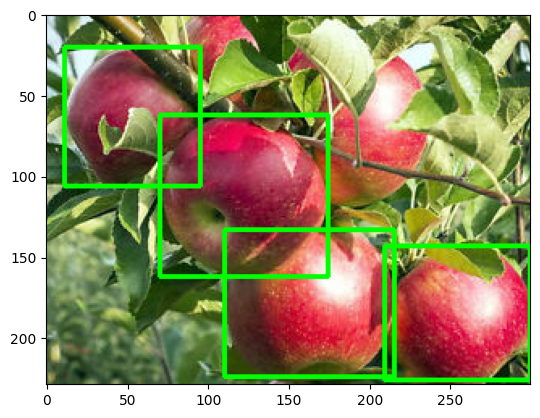

In [55]:
'''Display the image using matplotlib'''
plt.imshow(image_rgb)